# Phase 1/3 Data Analysis & Preprocessing

**Goal:** predict bone age (months) from a hand X-ray + gender.

In [1]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import io, os, shutil, zipfile
os.environ["NO_ALBUMENTATIONS_UPDATE"] = "1"  # evita il warning

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path
import io, os, shutil, zipfile
os.environ["NO_ALBUMENTATIONS_UPDATE"] = "1"

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

sys.path.append(str(Path("..").resolve()))
from src.data import compute_stats, pad_to_square, apply_clahe

try:
    import cv2
except ModuleNotFoundError:
    !{sys.executable} -m pip install opencv-python-headless
    import cv2

try:
    import cv2
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install opencv-python-headless
    import cv2
os.environ["NO_ALBUMENTATIONS_UPDATE"] = "1" # evita il warning

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path
from src.data import compute_stats, pad_to_square, apply_clahe

ModuleNotFoundError: No module named 'src'

In [ ]:
def extract_zip(zip_path: Path, dest: Path) -> None:
    dest.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf: zf.extractall(dest)

def extract_zip_flat(zip_path: Path, dest: Path) -> None:
    dest.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        for member in zf.namelist():
            if member.endswith("/"): continue
            filename = Path(member).name
            with zf.open(member) as src, open(dest / filename, "wb") as dst:
                dst.write(src.read())

 ## 1.1 Reproducible dataset's extraction

In [ ]:
Path("../data/raw").mkdir(parents=True, exist_ok=True)

print("Extracting training images")
extract_zip_flat(Path("../Sources/Bone+Age+Training+Set.zip"), Path("../data/raw/train") )

print("Extracting training annotations")
with zipfile.ZipFile(Path("../Sources/Bone+Age+Training+Set+Annotations.zip")) as zf:
    train_df = pd.read_csv(io.BytesIO(zf.read("train.csv")))
train_df["id"] = train_df["id"].astype(str)
train_df["male"] = train_df["male"].astype(int)
train_df.to_csv(Path("../data/raw") / "train_y.csv", index=False)

print("Extracting validation/test images")
tmp_dir = Path("../data/raw/tmp_validation")
extract_zip(Path("../Sources/Bone+Age+Validation+Set.zip"), tmp_dir)
extract_zip_flat(tmp_dir / "Bone Age Validation Set/boneage-validation-dataset-1.zip", Path("../data/raw/valid"))
extract_zip_flat(tmp_dir / "Bone Age Validation Set/boneage-validation-dataset-2.zip", Path("../data/raw/test"))

Extracting training images
Extracting training annotations
Extracting validation/test images


# 1.2 Fixing the alignment between train e valid-test

In [ ]:
# Rename annotations because they are different naming w.r.t training
vdf = pd.read_csv(tmp_dir / "Bone Age Validation Set/Validation Dataset.csv")
vdf = vdf.rename(columns={"Image ID": "id", "Bone Age (months)": "boneage"})
vdf["id"] = vdf["id"].astype(str)
vdf["male"] = vdf["male"].astype(str).str.strip().str.upper().map({"TRUE": 1, "FALSE": 0})
vdf["boneage"] = vdf["boneage"].astype(float)
vdf = vdf[["id", "boneage", "male"]]

# listing
valid_ids = {p.stem for p in Path("../data/raw/valid").rglob("*.png")}
test_ids = {p.stem for p in Path("../data/raw/test").rglob("*.png")}

# divide validation and test from annotations
valid_df = vdf[vdf["id"].isin(valid_ids)].reset_index(drop=True)
test_df = vdf[vdf["id"].isin(test_ids)].reset_index(drop=True)

# save and remove tmp files
valid_df.to_csv(Path("../data/raw/valid_y.csv"), index=False)
test_df.to_csv(Path("../data/raw/test_y.csv"), index=False)
shutil.rmtree(tmp_dir)

# holdout
dfs = {
    "train": train_df.assign(split="train"),
    "valid": valid_df.assign(split="valid"),
    "test": test_df.assign(split="test"),
}

## 1.3 Show Train-Valid-Test info

In [ ]:
print(f"Labels written: train={len(train_df)}  valid={len(valid_df)}  test={len(test_df)}")
for name, d in dfs.items():
    print(f'--- {name}: {len(d)} rows ---')
    display(d.head(3))

Labels written: train=12611  valid=800  test=625
--- train: 12611 rows ---


,id,boneage,male,split
0,1377,180,0,train
1,1378,12,0,train
2,1379,94,0,train


--- valid: 800 rows ---


,id,boneage,male,split
0,1386,30.0,0,valid
1,1392,162.0,1,valid
2,1397,18.0,0,valid


--- test: 625 rows ---


,id,boneage,male,split
0,9727,120.0,0,test
1,9731,84.0,1,test
2,9743,113.0,0,test


In [ ]:
all_df = pd.concat(dfs.values(), ignore_index=True)
print('Total labeled images:', len(all_df))
display(all_df.groupby('split')['boneage'].describe().round(1))

Total labeled images: 14036


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,625.0,127.0,39.5,12.0,96.0,132.0,156.0,228.0
train,12611.0,127.3,41.2,1.0,96.0,132.0,156.0,228.0
valid,800.0,127.3,43.4,3.0,96.0,132.0,156.0,228.0


## 1.4 Ground truth and gender distribution
(To understand if a target's normalization is required)

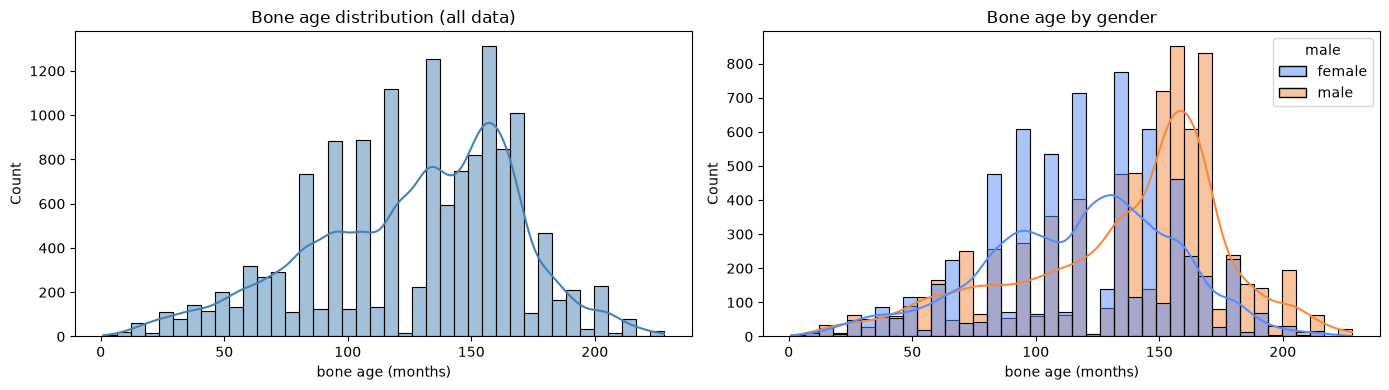

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(all_df['boneage'], bins=40, kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('Bone age distribution (all data)')
ax[0].set_xlabel('bone age (months)')
sns.histplot(data=all_df, x='boneage', hue=all_df['male'].map({0:'female',1:'male'}), bins=40, kde=True, ax=ax[1])
ax[1].set_title('Bone age by gender')
ax[1].set_xlabel('bone age (months)')
plt.tight_layout(); plt.show()

## 1.5 Preprocessing pipeline (example)

**pad-to-square → resize 256×256 → CLAHE.** CLAHE locally enhances contrast, sharpening bone edges/growth plates that carry the age signal.

In [ ]:
def show_images(images, titles=None, cols: int = 4, sup_title: str = ""):
    n = len(images)
    cols, rows = min(cols, n), int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 3.0 * rows))
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(images[i], cmap="gray")
            if titles is not None: ax.set_title(titles[i], fontsize=10)
        ax.axis("off")
    if sup_title: fig.suptitle(sup_title, fontsize=13)
    fig.tight_layout()
    return fig

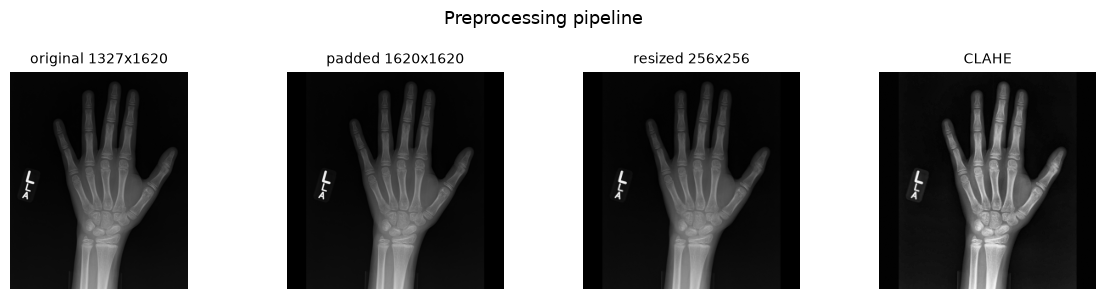

In [ ]:
raw = cv2.imread(Path("../data/raw/train/13624.png"), cv2.IMREAD_GRAYSCALE)

padded = pad_to_square(raw)
resized = cv2.resize(padded, (256, 256), interpolation=cv2.INTER_AREA)
clahe = apply_clahe(resized)

show_images([raw, padded, resized, clahe],
            titles=[
                f"original {raw.shape[1]}x{raw.shape[0]}",
                f"padded {padded.shape[1]}x{padded.shape[0]}",
                f"resized {resized.shape[1]}x{resized.shape[0]}",
                "CLAHE"],
            cols=4, sup_title="Preprocessing pipeline")

plt.show()

## 1.6 Build the preprocessed cache
(To speed up the training)

In [ ]:
for split, ids, raw_dir in [
    ("train", dfs["train"]["id"].tolist(), Path("../data/raw") / "train"),
    ("valid", dfs["valid"]["id"].tolist(), Path("../data/raw") / "valid"),
    ("test", dfs["test"]["id"].tolist(), Path("../data/raw") / "test"),
]:
    cache_dir = Path(f"../data/cache/{split}")
    cache_dir.mkdir(parents=True, exist_ok=True)
    index = {p.stem: p for p in raw_dir.rglob("*.png")} # rglob - automaticamente va dentro le cartelle
    for img_id in tqdm(ids, desc=f"caching -> {split}"):
        out = cache_dir / f"{img_id}.png"
        img = cv2.imread(index[img_id], cv2.IMREAD_GRAYSCALE)
        img = pad_to_square(img)
        img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_AREA)
        img = apply_clahe(img)
        cv2.imwrite(str(out), img)

In [ ]:
stats = compute_stats(dfs['train'])

pixel stats:   0%|          | 0/12611 [00:00<?, ?it/s]

Saved stats: {'pixel_mean': 0.18366464296491927, 'pixel_std': 0.21158708445779453, 'boneage_mean': 127.3207517246848, 'boneage_std': 41.18202139939633, 'n_images': 12611}
